In [89]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, mutual_info_score

from translate_dn_en import translate_danish_to_english 

In [90]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [91]:
model_id = "openai/clip-vit-large-patch14"
# load model and processor
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)
tokenizer = CLIPTokenizer.from_pretrained(model_id)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [92]:
# load the english data (generated in Blip2_zeroshot, can be changed)
df = pd.read_csv("metadata_en.csv") 

df = df.dropna(subset=["Image File", "Category"]) # drop rows with missing values (NaN)

# use the first 100, can be changed for other subsets
df = df[:100]
true_labels = list(df["Category"])
categories = list(df["Category"].unique())

image_paths = [
    os.path.join("images2", fname) # change images2 to name of folder with images
    for fname in df["Image File"]
]

label_to_idx = {label: i for i, label in enumerate(categories)}
true_idx = np.array([label_to_idx[l] for l in true_labels])

In [93]:
def normalize(x: np.ndarray):
    """L2-normalization of embeddings"""
    return x / np.linalg.norm(x, axis=1, keepdims=True)

In [94]:
def get_text_embeddings(text):
    """Encode category names into CLIP text embeddings"""
    prompt = [f"a photo of a {c}" for c in categories]
    text_inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(device)
    
    with torch.no_grad():
        label_emb = model.get_text_features(input_ids=text_inputs['input_ids'], attention_mask=text_inputs['attention_mask'])
    
    label_emb = label_emb.cpu().numpy()
    return normalize(label_emb)
    

In [95]:
def get_image_embedding(image_path: str, batch_size=32):
    """Encode images into CLIP image embeddings"""
    all_image_emb = []
    
    for i in  tqdm(range(0, len(image_paths), batch_size)):
        batch_paths = image_paths[i : i + batch_size]
        image = [Image.open(image_path).convert("RGB") for image_path in batch_paths]
        
        with torch.no_grad():
            inputs = processor(images=image, return_tensors="pt", padding=True).to(device)
            embeddings = model.get_image_features(**inputs)
            
        embeddings = embeddings.cpu().numpy()
        all_image_emb.append(embeddings)

    all_image_emb = np.vstack(all_image_emb) 
    return normalize(all_image_emb)

In [96]:
# encode text & images (are normalized in functions)
label_emb = get_text_embeddings(categories)
image_embeddings = get_image_embedding(image_paths, 32) # batch size can be changed

  0%|          | 0/4 [00:00<?, ?it/s]

In [97]:
# similarity scores using dot product of normalized embeddings
scores = np.dot(image_embeddings, label_emb.T)
# predictions (highest score)
preds = []
preds.extend(np.argmax(scores, axis=1))

In [98]:
categories[preds[2]]

'Electronics'

In [99]:
# calculate accuracy (percentage of correct predictions)
corect = 0
for i, label in enumerate(true_idx):
    if label == preds[i]:
        corect += 1
        
corect /len(image_paths) 

0.44

In [100]:
for i in range(10):
    print(
        "GT:", true_labels[i],
        "| Pred:", categories[preds[i]]
    )

GT: Recreation & Garden | Pred: Toys
GT: Lamps | Pred: Lamps
GT: Electronics | Pred: Electronics
GT: Recreation & Garden | Pred: Toys
GT: Housing | Pred: Kitchen stuff
GT: Housing | Pred: Furniture
GT: Recreation & Garden | Pred: Clothes and textiles
GT: Music & Books | Pred: Furniture
GT: Lamps | Pred: Lamps
GT: Music & Books | Pred: Housing


In [101]:
# Top-5 accuracy
top5 = np.argsort(scores, axis=1)[:, -5:]
top5_acc = np.mean([true_idx[i] in top5[i] for i in range(len(true_idx))])
print("Top-5 accuracy:", top5_acc)

Top-5 accuracy: 0.8


In [102]:
# saving predictions for comparison
df_clip = pd.DataFrame({
    "image_file": image_paths,
    "true_label": true_labels,
    "clip_pred": [categories[i] for i in preds]  # convert indices to names
})

df_clip.to_csv("clip_predictions.csv", index=False)

CLIP predictions saved!


In [84]:
labels = list(range(len(categories)))

# confusion matrix
cm = confusion_matrix(
    y_true=true_idx,
    y_pred=preds,
    labels=labels,
)

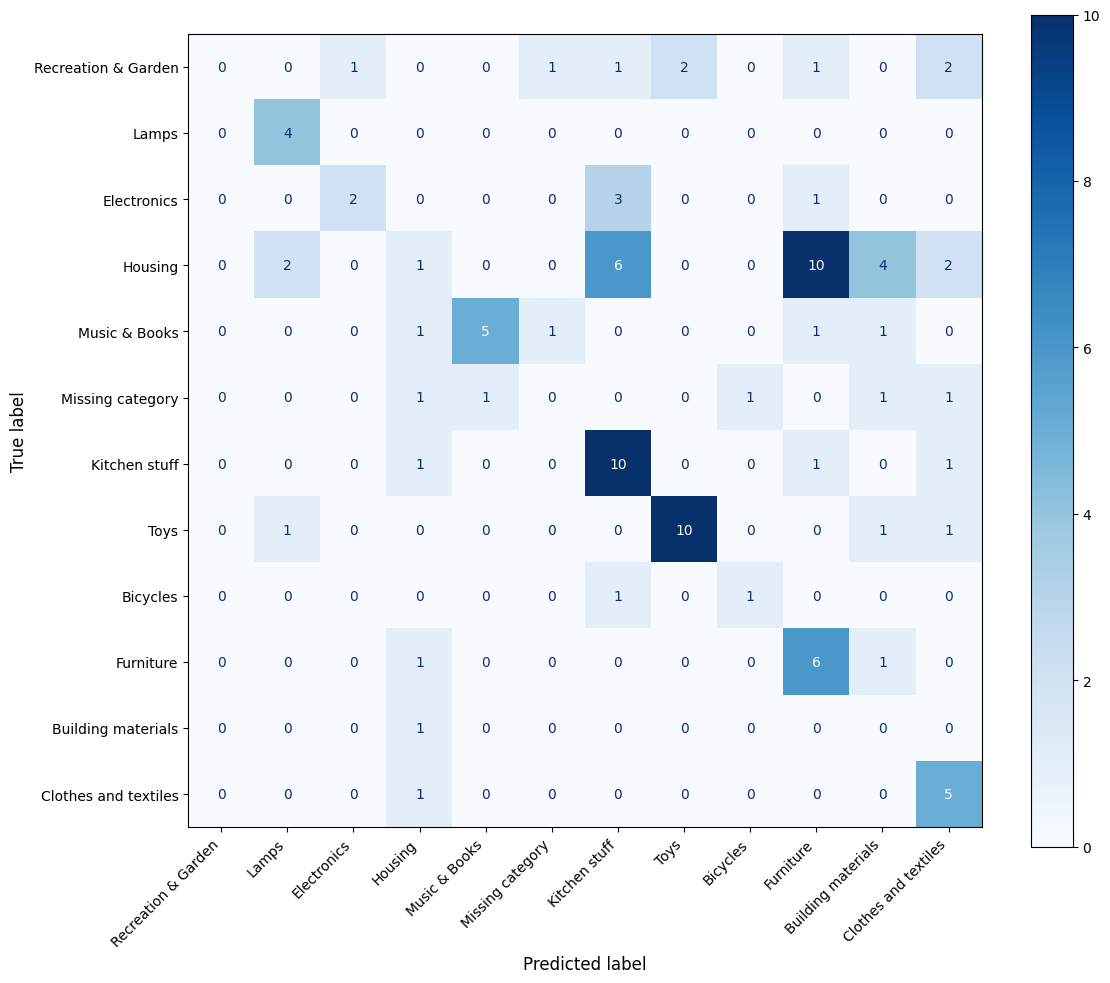

In [85]:
# plot figure (made bigger than default)
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categories
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    xticks_rotation=45
)

# fix label alignment
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.xticks(ha="right")  
plt.yticks(rotation=0)  

# plot
plt.tight_layout()
plt.show()

In [86]:
# print classification report
print(
    classification_report(
        y_true=true_idx,
        y_pred=preds,
        labels=list(range(len(categories))),
        target_names=categories,
    )
)

                      precision    recall  f1-score   support

 Recreation & Garden       0.00      0.00      0.00         8
               Lamps       0.57      1.00      0.73         4
         Electronics       0.67      0.33      0.44         6
             Housing       0.14      0.04      0.06        25
       Music & Books       0.83      0.56      0.67         9
    Missing category       0.00      0.00      0.00         5
       Kitchen stuff       0.48      0.77      0.59        13
                Toys       0.83      0.77      0.80        13
            Bicycles       0.50      0.50      0.50         2
           Furniture       0.30      0.75      0.43         8
  Building materials       0.00      0.00      0.00         1
Clothes and textiles       0.42      0.83      0.56         6

            accuracy                           0.44       100
           macro avg       0.40      0.46      0.40       100
        weighted avg       0.40      0.44      0.39       100



C:\Users\Sandra\PycharmProjects\ProductLifetime\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sandra\PycharmProjects\ProductLifetime\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Sandra\PycharmProjects\ProductLifetime\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [87]:
# mutual information score
print (
    mutual_info_score(labels_true=true_idx, labels_pred=preds)
)

1.0763665484514697
